In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Cihaz yapılandırması (Varsa GPU, yoksa CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")

# Hiperparametreler (Raporun 'Model Eğitimi' kısmında bunları tablo olarak ver)
num_epochs = 10
batch_size = 64
learning_rate = 0.001

Kullanılan Cihaz: cpu


In [3]:
# Dönüşümler (Preprocessing)
transform = transforms.Compose([
    transforms.Resize((32, 32)),     # Tüm görselleri 32x32 piksel yap
    transforms.ToTensor(),           # Tensör formatına çevir (0-1 arasına sıkıştırır)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalizasyon (-1 ile 1 arasına)
])

# NOT: GTSRB veri setini PyTorch otomatik indirebilir.
# Eğer hata alırsan manuel indirip 'root' kısmını değiştirmen gerekir.
train_dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.GTSRB(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

# DataLoader (Veriyi batch'ler halinde modele besler)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Eğitim Verisi Sayısı: {len(train_dataset)}")
print(f"Test Verisi Sayısı: {len(test_dataset)}")

100%|██████████| 187M/187M [00:06<00:00, 27.3MB/s]
100%|██████████| 89.0M/89.0M [00:04<00:00, 21.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 323kB/s]


Eğitim Verisi Sayısı: 26640
Test Verisi Sayısı: 12630


In [4]:
class TrafficSignNet(nn.Module):
    def __init__(self, num_classes=43): # GTSRB'de 43 sınıf var
        super(TrafficSignNet, self).__init__()

        # 1. Evrişim Bloğu
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=0), # Giriş: 3 kanal (RGB)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 2. Evrişim Bloğu
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Tam Bağlantılı Katmanlar (Fully Connected)
        # 32x32 giriş -> layer1 sonrası 14x14 -> layer2 sonrası 5x5
        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.dropout = nn.Dropout(0.5) # Overfitting'i önlemek için
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1) # Flatten (Düzleştirme)
        out = self.fc1(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

model = TrafficSignNet().to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Grafikler için verileri tutacağımız listeler
loss_list = []
accuracy_list = []

print("Eğitim Başlıyor...")

for epoch in range(num_epochs):
    model.train() # Modeli eğitim moduna al
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass (İleri yayılım)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass (Geri yayılım ve optimizasyon)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Doğruluk hesaplama (Anlık takip için)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    loss_list.append(epoch_loss)
    accuracy_list.append(epoch_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: %{epoch_acc:.2f}')

print("Eğitim Tamamlandı.")

Eğitim Başlıyor...
Epoch [1/10], Loss: 0.7890, Accuracy: %77.78
Epoch [2/10], Loss: 0.1921, Accuracy: %94.76
Epoch [3/10], Loss: 0.1432, Accuracy: %95.97
Epoch [4/10], Loss: 0.0976, Accuracy: %97.34
Epoch [5/10], Loss: 0.0881, Accuracy: %97.61
Epoch [6/10], Loss: 0.0673, Accuracy: %98.09
Epoch [7/10], Loss: 0.0693, Accuracy: %98.10
Epoch [8/10], Loss: 0.0456, Accuracy: %98.80
Epoch [9/10], Loss: 0.0431, Accuracy: %98.81
Epoch [10/10], Loss: 0.0665, Accuracy: %98.33
Eğitim Tamamlandı.


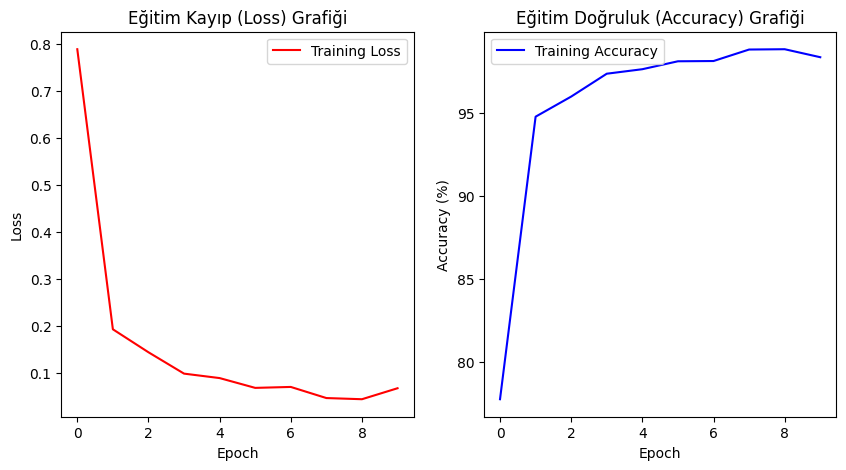

In [6]:
plt.figure(figsize=(10, 5))

# Loss Grafiği
plt.subplot(1, 2, 1)
plt.plot(loss_list, label='Training Loss', color='red')
plt.title('Eğitim Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Grafiği
plt.subplot(1, 2, 2)
plt.plot(accuracy_list, label='Training Accuracy', color='blue')
plt.title('Eğitim Doğruluk (Accuracy) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

Test verisi üzerinde tahminler yapılıyor...
Tahminler tamamlandı. Rapor oluşturuluyor...

--- Özet Sınıflandırma Raporu ---
   precision    recall  f1-score  support
0   0.852459  0.866667  0.859504     60.0
1   0.894015  0.995833  0.942181    720.0
2   0.982759  0.988000  0.985372    750.0
3   0.924370  0.977778  0.950324    450.0
4   0.957640  0.959091  0.958365    660.0

Genel Test Doğruluğu (Accuracy): %93.92


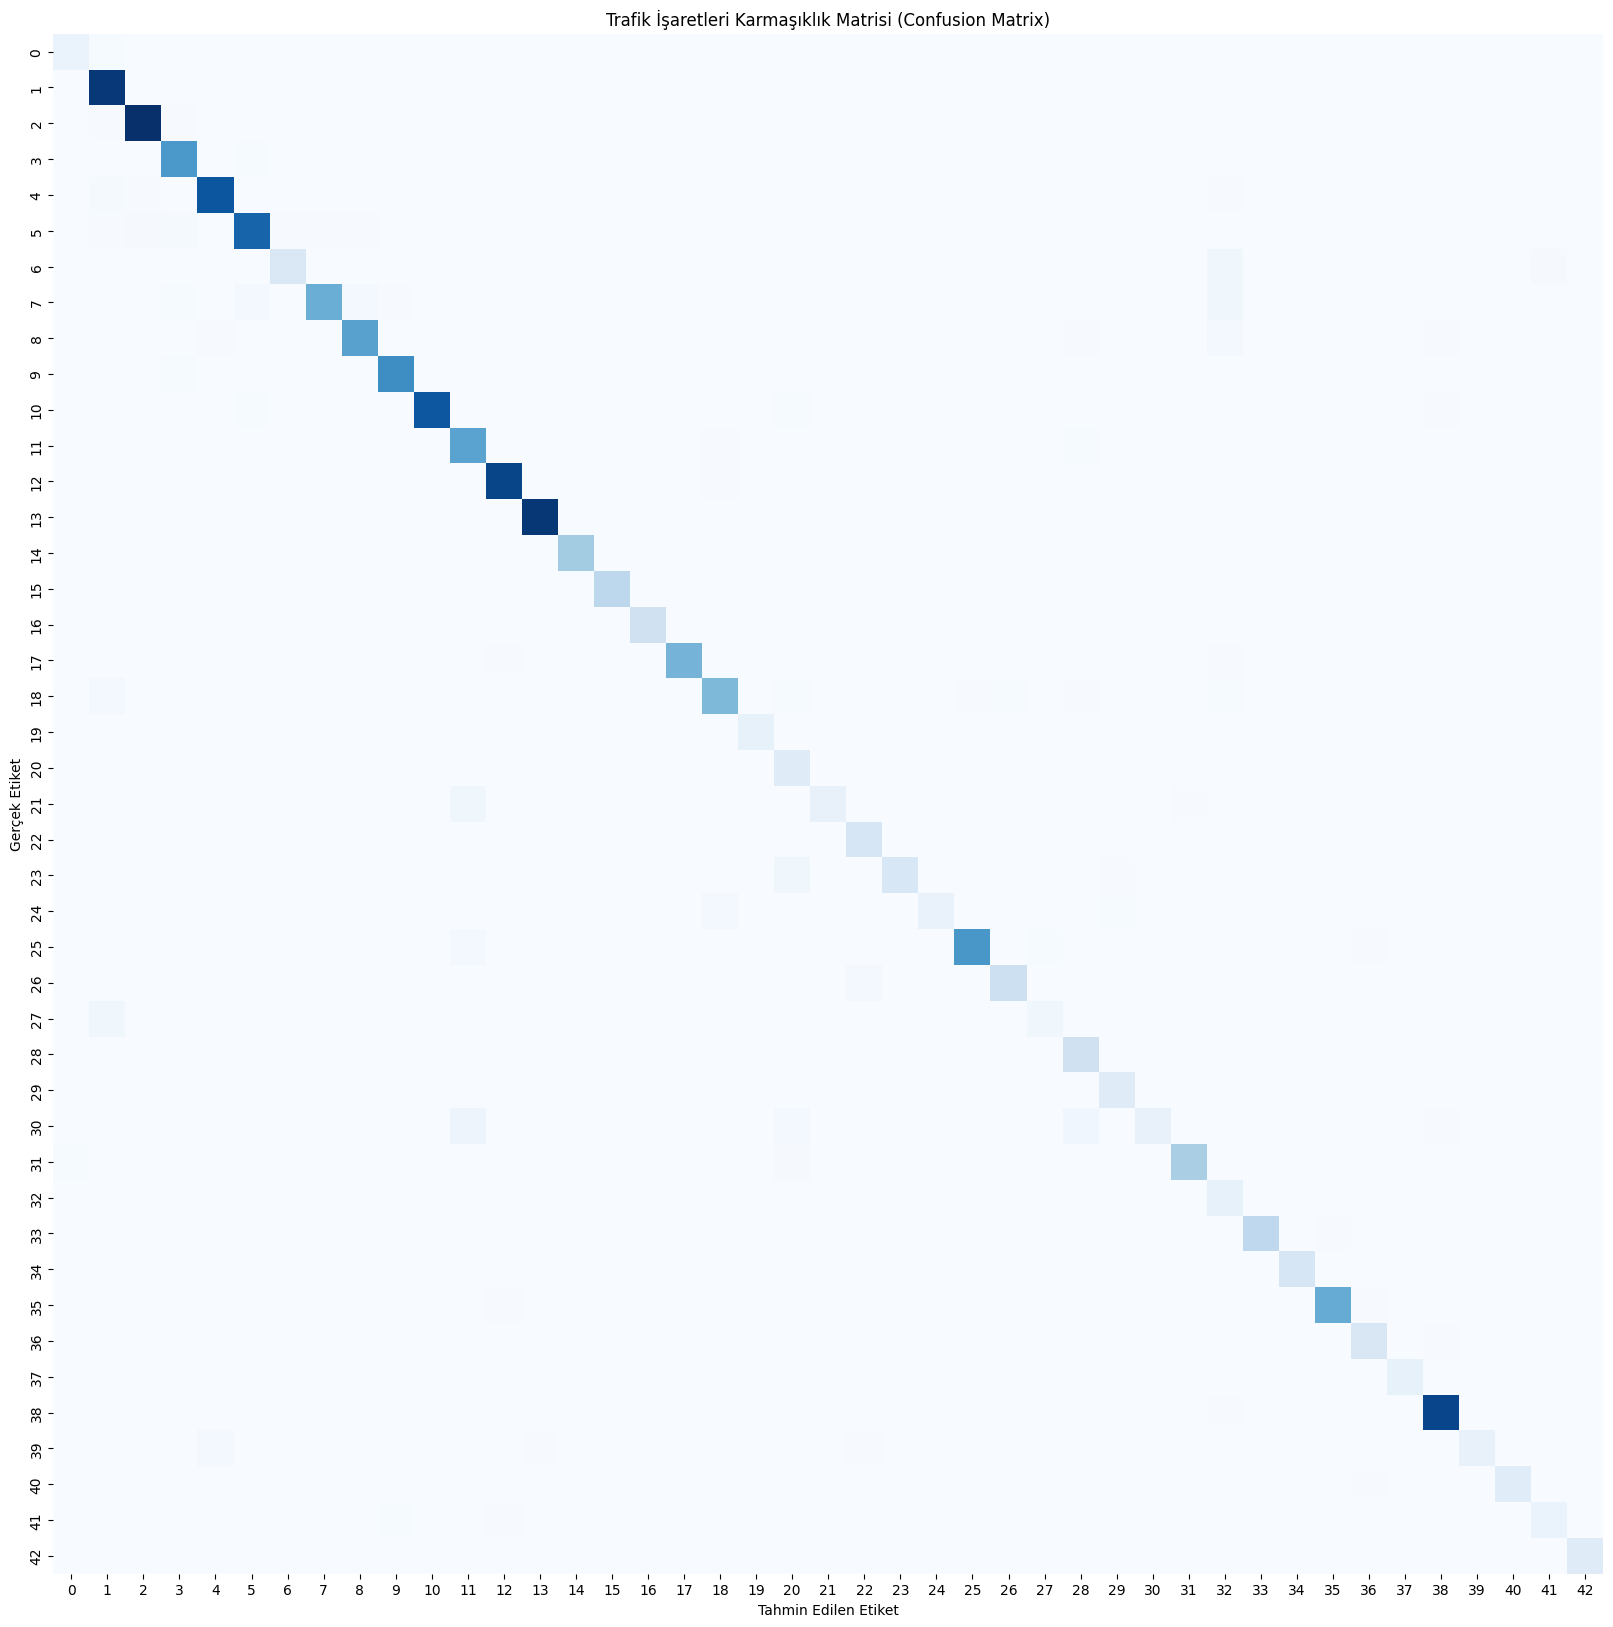

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Modeli Değerlendirme Moduna Al (Önemli!)
model.eval()

y_true = [] # Gerçek etiketler
y_pred = [] # Modelin tahminleri

print("Test verisi üzerinde tahminler yapılıyor...")

# Gradyan hesaplamayı kapatıyoruz (Hız ve hafıza için)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        # GPU'daki tensörleri CPU'ya alıp listeye ekliyoruz
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Tahminler tamamlandı. Rapor oluşturuluyor...")

# -------------------------------------------------------
# 2. Detaylı Sınıflandırma Raporu (Classification Report)
# -------------------------------------------------------
# Bu rapor her bir trafik işareti için ayrı ayrı başarıyı gösterir.
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Raporu ekrana basalım (Sadece ilk 5 satır örnek olarak)
print("\n--- Özet Sınıflandırma Raporu ---")
print(df_report.head())

# Genel Test Doğruluğu
test_accuracy = 100 * (np.array(y_true) == np.array(y_pred)).sum() / len(y_true)
print(f"\nGenel Test Doğruluğu (Accuracy): %{test_accuracy:.2f}")

# -------------------------------------------------------
# 3. Karmaşıklık Matrisi (Confusion Matrix) Görselleştirme
# -------------------------------------------------------
# Modelin hangi sınıfı hangi sınıfla karıştırdığını gösterir.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20)) # Büyük bir grafik açıyoruz çünkü 43 sınıf var
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False)
# annot=True yaparsan sayıları yazar ama 43 sınıfta çok karışabilir.

plt.title('Trafik İşaretleri Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.show()

In [8]:
torch.save(model.state_dict(), 'traffic_sign_cnn.pth')
print("Model başarıyla kaydedildi.")

Model başarıyla kaydedildi.


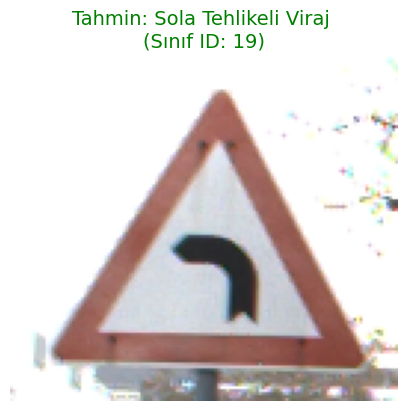

Modelin Tahmini: Sola Tehlikeli Viraj


In [26]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. GTSRB Sınıf İsimleri (Modelin çıktısını Türkçeye çevirmek için)
classes = {
    0:'Hız Limiti (20km/s)',
    1:'Hız Limiti (30km/s)',
    2:'Hız Limiti (50km/s)',
    3:'Hız Limiti (60km/s)',
    4:'Hız Limiti (70km/s)',
    5:'Hız Limiti (80km/s)',
    6:'Hız Limiti Sonu (80km/s)',
    7:'Hız Limiti (100km/s)',
    8:'Hız Limiti (120km/s)',
    9:'Geçiş Yok',
    10:'Kamyonlar için geçiş yok',
    11:'Ana yol tali yol kavşağı',
    12:'Anayol',
    13:'Yol Ver',
    14:'DUR (Stop)',
    15:'Taşıt Giremez',
    16:'Kamyon Giremez',
    17:'Girişi Olmayan Yol',
    18:'Dikkat',
    19:'Sola Tehlikeli Viraj',
    20:'Sağa Tehlikeli Viraj',
    21:'Birbiri ardına tehlikeli virajlar',
    22:'Engebeli Yol',
    23:'Kaygan Yol',
    24:'Sağdan Daralan Yol',
    25:'Yol Çalışması',
    26:'Trafik Işıkları',
    27:'Yaya Geçidi',
    28:'Okul Geçidi',
    29:'Bisiklet Geçidi',
    30:'Buzlanma Uyarısı',
    31:'Vahşi Hayvan Çıkabilir',
    32:'Hız Sınırı ve Yasaklar Sonu',
    33:'Sağa Mecburi Yön',
    34:'Sola Mecburi Yön',
    35:'İleri ve Sağa Mecburi Yön',
    36:'İleri ve Sola Mecburi Yön',
    37:'Sola Dönüş Yok',
    38:'Sağa Dönüş Yok',
    39:'Sol Tarafı İzleyiniz',
    40:'Sağ Tarafı İzleyiniz',
    41:'Geçiş Yasağı Sonu',
    42:'Kamyonlar için geçiş yasağı sonu'
}

def predict_external_image(image_path):
    # Resmi aç ve RGB'ye çevir (Bazı resimler RGBA olabilir, hata vermemesi için)
    img = Image.open(image_path).convert('RGB')

    # Görüntüyü eğitimdeki gibi işle (Resize + Normalize)
    # NOT: Eğitimdeki transform değişkenini aynen kullanıyoruz
    img_transformed = transform(img)

    # Modelin beklediği batch boyutunu ekle: (3, 32, 32) -> (1, 3, 32, 32)
    img_batch = img_transformed.unsqueeze(0).to(device)

    # Tahmin yap
    model.eval()
    with torch.no_grad():
        outputs = model(img_batch)
        _, predicted = torch.max(outputs, 1)

    class_id = predicted.item()
    class_name = classes[class_id]

    # Sonucu Görselleştir
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Tahmin: {class_name} \n(Sınıf ID: {class_id})", color='green', fontsize=14)
    plt.show()

    return class_name

# --- TEST KISMI ---
# Buraya indirdiğin resmin adını yaz
image_path = "dlcsign.png"
try:
    prediction = predict_external_image(image_path)
    print(f"Modelin Tahmini: {prediction}")
except FileNotFoundError:
    print(f"Hata: '{image_path}' dosyası bulunamadı. Lütfen dosya yolunu kontrol et.")